In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/master_sales.csv', parse_dates=['sale_date'])

In [3]:
# Aggregate: Total daily sales across all stores
daily_sales = df.groupby('sale_date')['sales'].sum().reset_index()
daily_sales.set_index('sale_date', inplace=True)
daily_sales = daily_sales.asfreq('D')  # Set daily frequency
daily_sales['sales'] = daily_sales['sales'].fillna(method='ffill')

print(f"Date range: {daily_sales.index.min()} to {daily_sales.index.max()}")
print(f"Total days: {len(daily_sales)}")

Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Total days: 1688


In [6]:
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(f'--- ADF Test: {title} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Stationary: {"Yes" if result[1] < 0.05 else "No (needs differencing)"}')
    print()

# Test original series
adf_test(daily_sales['sales'], 'Original Series')

# If not stationary, difference it
adf_test(daily_sales['sales'].diff().dropna(), 'First Difference')

--- ADF Test: Original Series ---
ADF Statistic: -2.8723
p-value: 0.048671
Stationary: Yes

--- ADF Test: First Difference ---
ADF Statistic: -10.9398
p-value: 0.000000
Stationary: Yes



Train: 2013-01-01 00:00:00 to 2017-07-16 00:00:00 (1658 days)
Test:  2017-07-17 00:00:00 to 2017-08-15 00:00:00 (30 days)


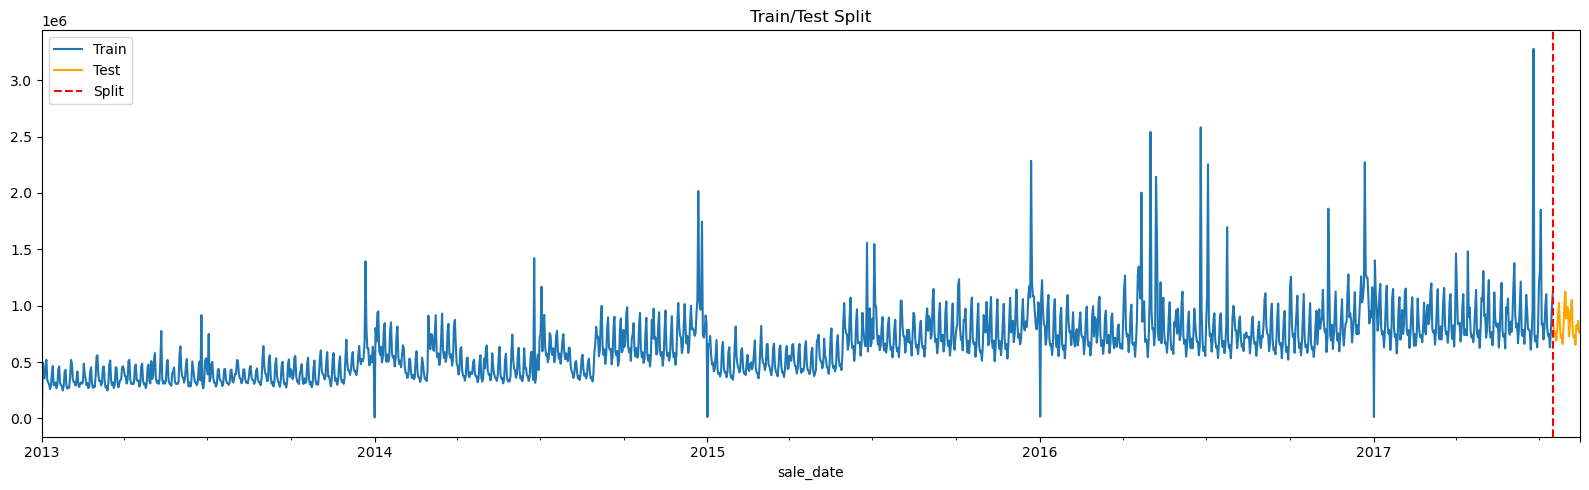

In [7]:
# Use last 30 days as test set
split_date = daily_sales.index.max() - pd.Timedelta(days=30)
train = daily_sales[:split_date]
test = daily_sales[split_date + pd.Timedelta(days=1):]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} days)")
print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} days)")

# Plot split
fig, ax = plt.subplots(figsize=(16, 5))
train['sales'].plot(ax=ax, label='Train')
test['sales'].plot(ax=ax, label='Test', color='orange')
ax.axvline(x=split_date, color='red', linestyle='--', label='Split')
ax.set_title('Train/Test Split')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/train_test_split.png', dpi=150)
plt.show()

In [9]:
# Simplified grid search (full grid takes too long on 3M data)
# For daily data with weekly seasonality, use m=7

from itertools import product as iter_product

p_values = [0, 1, 2]
d_values = [0,1]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [1]
Q_values = [0, 1]
m = 7  # Weekly seasonality

best_aic = np.inf
best_params = None

# Use a subset for parameter search (last 365 days of training data)
train_subset = train[-365:]

print("Searching for best parameters... (this may take 10-20 minutes)")
for p, d, q, P, D, Q in iter_product(p_values, d_values, q_values, P_values, D_values, Q_values):
    try:
        model = SARIMAX(train_subset['sales'],
                       order=(p, d, q),
                       seasonal_order=(P, D, Q, m),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
        result = model.fit(disp=False, maxiter=100)
        if result.aic < best_aic:
            best_aic = result.aic
            best_params = (p, d, q, P, D, Q)
            print(f"  New best: ({p},{d},{q})x({P},{D},{Q},{m}) AIC={result.aic:.2f}")
    except:
        continue

print(f"\nBest params: ({best_params[0]},{best_params[1]},{best_params[2]})x({best_params[3]},{best_params[4]},{best_params[5]},{m})")
print(f"Best AIC: {best_aic:.2f}")

Searching for best parameters... (this may take 10-20 minutes)
  New best: (0,0,0)x(0,1,0,7) AIC=9979.59
  New best: (0,0,0)x(0,1,1,7) AIC=9639.68
  New best: (0,0,1)x(0,1,1,7) AIC=9633.36
  New best: (0,0,2)x(0,1,1,7) AIC=9603.94
  New best: (1,0,2)x(0,1,1,7) AIC=9589.42

Best params: (1,0,2)x(0,1,1,7)
Best AIC: 9589.42


In [10]:
# Train on full training data with best parameters
p, d, q, P, D, Q = best_params

model = SARIMAX(train['sales'],
               order=(p, d, q),
               seasonal_order=(P, D, Q, m),
               enforce_stationarity=False,
               enforce_invertibility=False)

results = model.fit(disp=True)
print(results.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               sales   No. Observations:                 1658
Model:             SARIMAX(1, 0, 2)x(0, 1, [1], 7)   Log Likelihood              -22175.699
Date:                             Thu, 30 Jul 2026   AIC                          44361.397
Time:                                     20:03:07   BIC                          44388.413
Sample:                                 01-01-2013   HQIC                         44371.416
                                      - 07-16-2017                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9750      0.014     71.064      0.000       0.948       1.002
ma.L1         -0.7076      

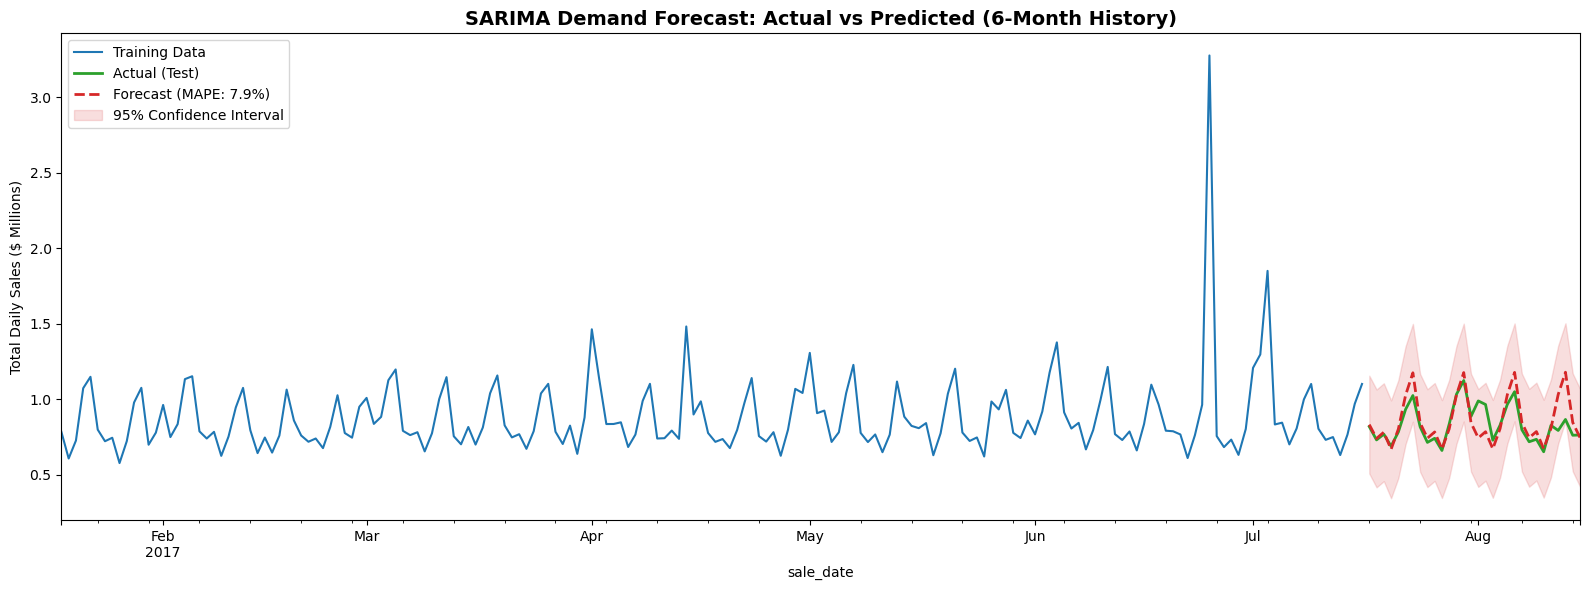

In [13]:
# 1. Convert all data to Millions ($M)
# Sliced to [-180:] to show exactly 6 months of training data
train_m = train['sales'][-180:] / 1e6
test_m = test['sales'] / 1e6
forecast_m = forecast / 1e6
std_error_m = results.resid.std() / 1e6

# 2. Plot actual vs predicted (6-MONTH HISTORY, in $ Millions)
fig, ax = plt.subplots(figsize=(16, 6))

train_m.plot(ax=ax, label='Training Data', color='#1f77b4')
test_m.plot(ax=ax, label='Actual (Test)', color='#2ca02c', linewidth=2)
forecast_m.plot(ax=ax, label=f'Forecast (MAPE: {mape:.1f}%)', color='#d62728', linewidth=2, linestyle='--')

ax.fill_between(test.index,
                forecast_m - 1.96 * std_error_m,
                forecast_m + 1.96 * std_error_m,
                alpha=0.15, color='#d62728', label='95% Confidence Interval')

ax.set_title('SARIMA Demand Forecast: Actual vs Predicted (6-Month History)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Daily Sales ($ Millions)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/forecast_results_6months_M.png', dpi=150)
plt.show()

In [14]:
# Combine actual + forecast for Power BI
forecast_df = pd.DataFrame({
    'date': test.index,
    'actual_sales': test['sales'].values,
    'forecasted_sales': forecast.values,
    'lower_bound': (forecast - 1.96 * results.resid.std()).values,
    'upper_bound': (forecast + 1.96 * results.resid.std()).values,
})
forecast_df['error'] = forecast_df['actual_sales'] - forecast_df['forecasted_sales']
forecast_df['error_pct'] = (abs(forecast_df['error']) / forecast_df['actual_sales'] * 100).round(2)

forecast_df.to_csv('../outputs/forecast_results.csv', index=False)
print("Saved forecast_results.csv for Power BI")
print(forecast_df.head(10))

Saved forecast_results.csv for Power BI
        date  actual_sales  forecasted_sales    lower_bound   upper_bound  \
0 2017-07-17    818325.522      8.314059e+05  507140.254630  1.155672e+06   
1 2017-07-18    730133.709      7.398768e+05  415611.148629  1.064142e+06   
2 2017-07-19    767978.778      7.810004e+05  456734.774257  1.105266e+06   
3 2017-07-20    688288.068      6.677082e+05  343442.538208  9.919739e+05   
4 2017-07-21    782418.299      8.017949e+05  477529.261253  1.126061e+06   
5 2017-07-22    932902.047      1.027030e+06  702764.180683  1.351296e+06   
6 2017-07-23   1024288.741      1.174801e+06  850535.317551  1.499067e+06   
7 2017-07-24    816564.327      8.423050e+05  518039.366081  1.166571e+06   
8 2017-07-25    713581.633      7.415929e+05  417327.200153  1.065859e+06   
9 2017-07-26    740653.044      7.826736e+05  458407.878206  1.106939e+06   

           error  error_pct  
0  -13080.407960       1.60  
1   -9743.114959       1.33  
2  -13021.671587      